In [4]:
import pandas as pd
import numpy as np

# 각 후보지별 지표 수치를 입력
data = {
    '후보지': [f'후보지 {i}' for i in range(1, 8)],
    '교통편의성 지수': [6, 29, 11, 16, 9, 0, 6],
    '교통위험성 지수': [0, 0, 0, 0, 1, 2, 0],
    '교통안전성 지수': [16, 8, 12, 7, 17, 14, 3],
    '주차편의성 지수': [64, 3, 75, 1, 0, 15, 0],
}

df = pd.DataFrame(data)

# Min-Max 정규화 함수
def min_max_normalize(series):
    return (series - series.min()) / (series.max() - series.min())

# 정규화된 값 계산
df['교통편의성 지수'] = min_max_normalize(df['교통편의성 지수'])
df['교통위험성 지수'] = 1 - min_max_normalize(df['교통위험성 지수'])  # 낮을수록 좋음
df['교통안전성 지수'] = min_max_normalize(df['교통안전성 지수'])
df['주차편의성 지수'] = min_max_normalize(df['주차편의성 지수'])

# 입지계수 계산
df['최적입지 점수'] = (
    df['교통편의성 지수']
    + df['교통위험성 지수']
    + df['교통안전성 지수']
    + df['주차편의성 지수']
)

# 필요한 열만 정리해서 출력
result_df = df[['후보지', '교통편의성 지수', '교통위험성 지수', '교통안전성 지수', '주차편의성 지수', '최적입지 점수']]
result_df.sort_values(by='최적입지 점수', ascending=False, inplace=True)
result_df.reset_index(drop=True, inplace=True)

result_df


,후보지,교통편의성 지수,교통위험성 지수,교통안전성 지수,주차편의성 지수,최적입지 점수
0,후보지 3,0.379310,1.0,0.642857,1.000000,3.022167
1,후보지 1,0.206897,1.0,0.928571,0.853333,2.988801
2,후보지 2,1.000000,1.0,0.357143,0.040000,2.397143
3,후보지 4,0.551724,1.0,0.285714,0.013333,1.850772
4,후보지 5,0.310345,0.5,1.000000,0.000000,1.810345
5,후보지 7,0.206897,1.0,0.000000,0.000000,1.206897
6,후보지 6,0.000000,0.0,0.785714,0.200000,0.985714


In [5]:
# 엑셀 파일로 저장
output_path = "후보지_입지계수.xlsx"
result_df.to_excel(output_path, index=False)

print(f"엑셀 파일 저장 완료: {output_path}")
result_df

엑셀 파일 저장 완료: 후보지_입지계수.xlsx


,후보지,교통편의성 지수,교통위험성 지수,교통안전성 지수,주차편의성 지수,최적입지 점수
0,후보지 3,0.379310,1.0,0.642857,1.000000,3.022167
1,후보지 1,0.206897,1.0,0.928571,0.853333,2.988801
2,후보지 2,1.000000,1.0,0.357143,0.040000,2.397143
3,후보지 4,0.551724,1.0,0.285714,0.013333,1.850772
4,후보지 5,0.310345,0.5,1.000000,0.000000,1.810345
5,후보지 7,0.206897,1.0,0.000000,0.000000,1.206897
6,후보지 6,0.000000,0.0,0.785714,0.200000,0.985714


In [6]:
# 3.4 버전 이상
# 시각화를 위한 설치, import

!pip install pandas matplotlib
!apt-get -qq install fonts-nanum

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

fe = fm.FontEntry(
    fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf', # ttf 파일이 저장되어 있는 경로
    name='NanumGothic')                        # 이 폰트의 원하는 이름 설정
fm.fontManager.ttflist.insert(0, fe)              # Matplotlib에 폰트 추가
plt.rcParams.update({'font.size': 18, 'font.family': 'NanumGothic'}) # 폰트 설정


<Figure size 1200x600 with 0 Axes>

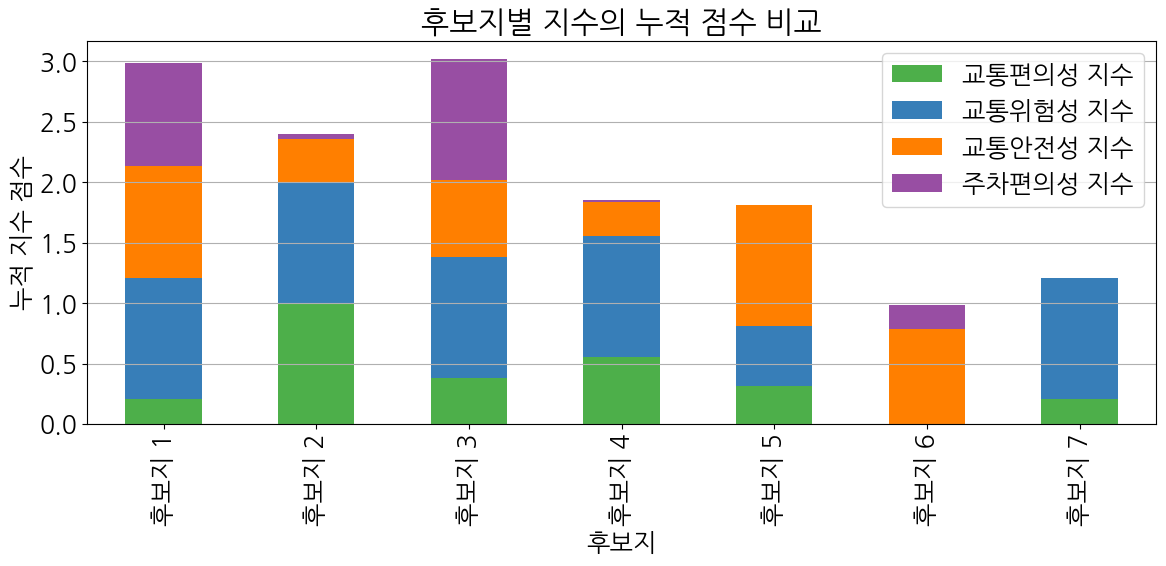

In [7]:
# 누적 막대그래프용 데이터 준비
stacked_data = df[['후보지', '교통편의성 지수', '교통위험성 지수', '교통안전성 지수', '주차편의성 지수']].set_index('후보지')

# 시각화
plt.figure(figsize=(12, 6))
stacked_data.plot(kind='bar', stacked=True, figsize=(12, 6),
                  color=['#4daf4a', '#377eb8', '#ff7f00', '#984ea3'])

plt.title('후보지별 지수의 누적 점수 비교')
plt.ylabel('누적 지수 점수')
plt.xlabel('후보지')
plt.legend(loc='upper right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()
